In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")

In [8]:
# Import Hotel bookings data from CSV file
df=pd.read_csv("hotel_bookings.csv")
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [15]:
#Find data shape and no of colomns
print(df.shape)
df.columns


(119390, 32)


Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [40]:
print("Active Reservation status values: ",df[df['is_canceled']==0]['reservation_status'].unique())
print("Cancelled Resrv. status values:",df[df['is_canceled']==1]['reservation_status'].unique())

Active Reservation status values:  ['Check-Out']
Cancelled Resrv. status values: ['Canceled' 'No-Show']


In [42]:
df[df['is_canceled']==1] ['reservation_status'].unique()

array(['Canceled', 'No-Show'], dtype=object)

In [27]:
df[df['is_canceled']==0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [ ]:
### BOOKING BY DIFFERENT TYPE OF HOTELS

/var/folders/6q/45jjl7ms5j504p5mdhyqtk3w0000gn/T/ipykernel_1570/1582431264.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=d.index, y=d, palette='Set2')


Text(0.5, 1.0, 'No of Bookings by hotel type')

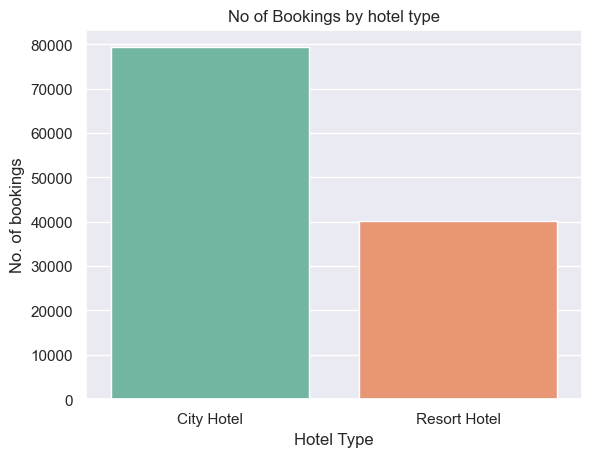

In [90]:
d = df.groupby('hotel')['hotel'].count()
sns.barplot(x=d.index, y=d, palette='Set2')
plt.xlabel("Hotel Type")
plt.ylabel("No. of bookings")
plt.title("No of Bookings by hotel type")

In [73]:
df.groupby('hotel')['hotel'].count()

hotel
City Hotel      79330
Resort Hotel    40060
Name: hotel, dtype: int64

In [56]:
grp=df.groupby('hotel')
print(grp.first())

              is_canceled  lead_time  arrival_date_year arrival_date_month  \
hotel                                                                        
City Hotel              0          6               2015               July   
Resort Hotel            0        342               2015               July   

              arrival_date_week_number  arrival_date_day_of_month  \
hotel                                                               
City Hotel                          27                          1   
Resort Hotel                        27                          1   

              stays_in_weekend_nights  stays_in_week_nights  adults  children  \
hotel                                                                           
City Hotel                          0                     2       1       0.0   
Resort Hotel                        0                     0       2       0.0   

              ...  deposit_type  agent company days_in_waiting_list  \
hotel         

In [ ]:
### Counts of Cancelled vs Not-Cancelled Bookings in different types of hotels

Text(0, 0.5, 'count')

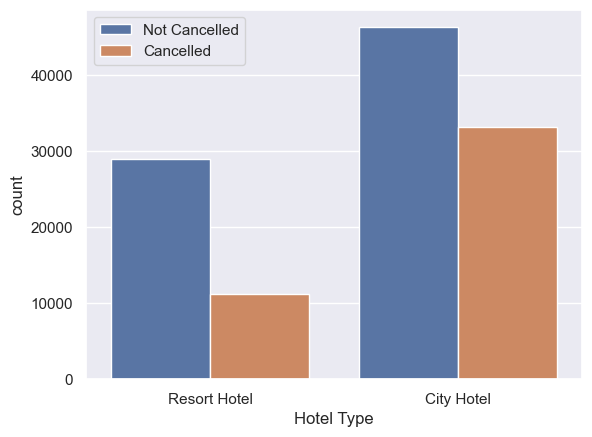

In [97]:
sns.countplot(x='hotel', hue='is_canceled', data=df)
plt.legend(['Not Cancelled', 'Cancelled'])
plt.xlabel("Hotel Type")
plt.ylabel("count")

In [ ]:
 ###   BOOKING BY YEAR AND TYPE OF HOTEL

In [98]:
df['arrival_date_year'].unique()

array([2015, 2016, 2017])

Text(0.5, 1.0, 'Total bookings by year')

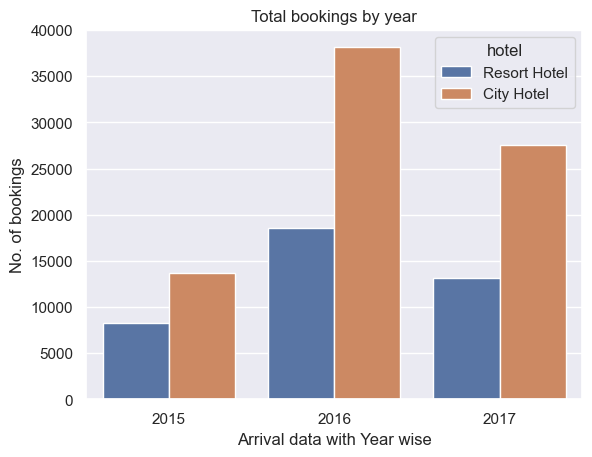

In [95]:
sns.countplot(x='arrival_date_year', hue='hotel', data=df)
plt.xlabel("Arrival data with Year wise")
plt.ylabel("No. of bookings")
plt.title("Total bookings by year")

In [ ]:
### NO OF BOOKINGS PER IN EVERY MONTHS

In [106]:
Months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

In [107]:
d = df.groupby("arrival_date_month")["arrival_date_month"].count()
print(d)

arrival_date_month
April        11089
August       13877
December      6780
February      8068
January       5929
July         12661
June         10939
March         9794
May          11791
November      6794
October      11160
September    10508
Name: arrival_date_month, dtype: int64


Text(0.5, 1.0, 'Bookings by months')

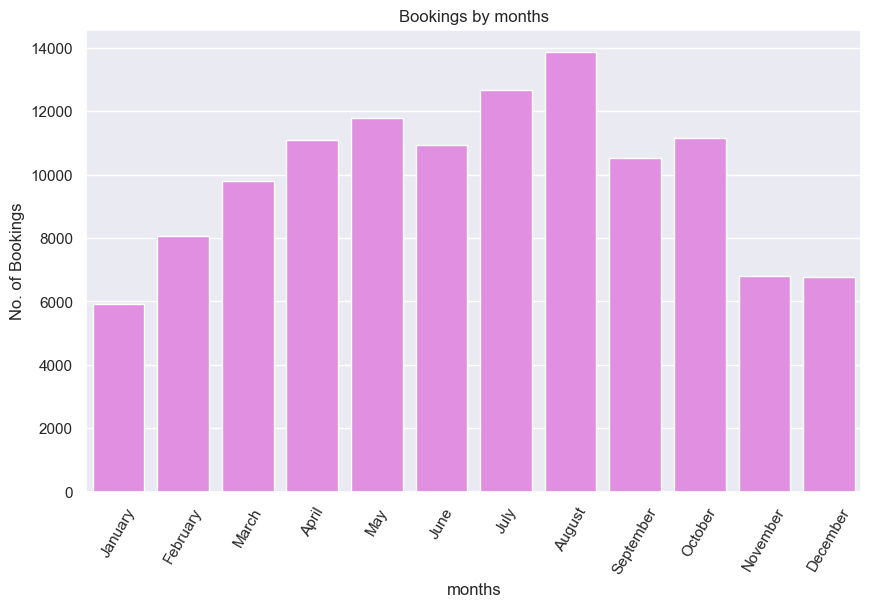

In [113]:
data =df.groupby("arrival_date_month")["arrival_date_month"].count()
plt.figure(figsize=(10,6))
sns.barplot(x=data.index, y=data, order=Months, color='violet')
p = plt.xticks(rotation=60)
plt.xlabel("months")
plt.ylabel("No. of Bookings")
plt.title("Bookings by months")

In [114]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [121]:
data_country = df['country'].value_counts()
data_country.describe()

count      177.000000
mean       671.762712
std       3931.154035
min          1.000000
25%          2.000000
50%         12.000000
75%         74.000000
max      48590.000000
Name: count, dtype: float64

In [ ]:
### TOP 20 COUNTRIES BY NO OF GUESTS DETAILS

In [122]:
country=df['country'].unique()
print(country)

['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' nan 'ROU' 'NOR' 'OMN' 'ARG' 'POL'
 'DEU' 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS' 'EST'
 'CZE' 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX' 'MAR'
 'UKR' 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF' 'AGO'
 'ISR' 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN' 'JAM'
 'HRV' 'HKG' 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL' 'GGY'
 'KWT' 'NGA' 'MDV' 'VEN' 'SVK' 'FJI' 'KAZ' 'PAK' 'IDN' 'LBN' 'PHL' 'SEN'
 'SYC' 'AZE' 'BHR' 'NZL' 'THA' 'DOM' 'MKD' 'MYS' 'ARM' 'JPN' 'LKA' 'CUB'
 'CMR' 'BIH' 'MUS' 'COM' 'SUR' 'UGA' 'BGR' 'CIV' 'JOR' 'SYR' 'SGP' 'BDI'
 'SAU' 'VNM' 'PLW' 'QAT' 'EGY' 'PER' 'MLT' 'MWI' 'ECU' 'MDG' 'ISL' 'UZB'
 'NPL' 'BHS' 'MAC' 'TGO' 'TWN' 'DJI' 'STP' 'KNA' 'ETH' 'IRQ' 'HND' 'RWA'
 'KHM' 'MCO' 'BGD' 'IMN' 'TJK' 'NIC' 'BEN' 'VGB' 'TZA' 'GAB' 'GHA' 'TMP'
 'GLP' 'KEN' 'LIE' 'GNB' 'MNE' 'UMI' 'MYT' 'FRO' 'MMR' 'PAN' 'BFA' 'LBY'
 'MLI' 'NAM' 'BOL' 'PRY' 'BRB' 'ABW' 'AIA' 'SLV' 'DMA'

Text(0.5, 1.0, 'Top 20 countries by number of guests')

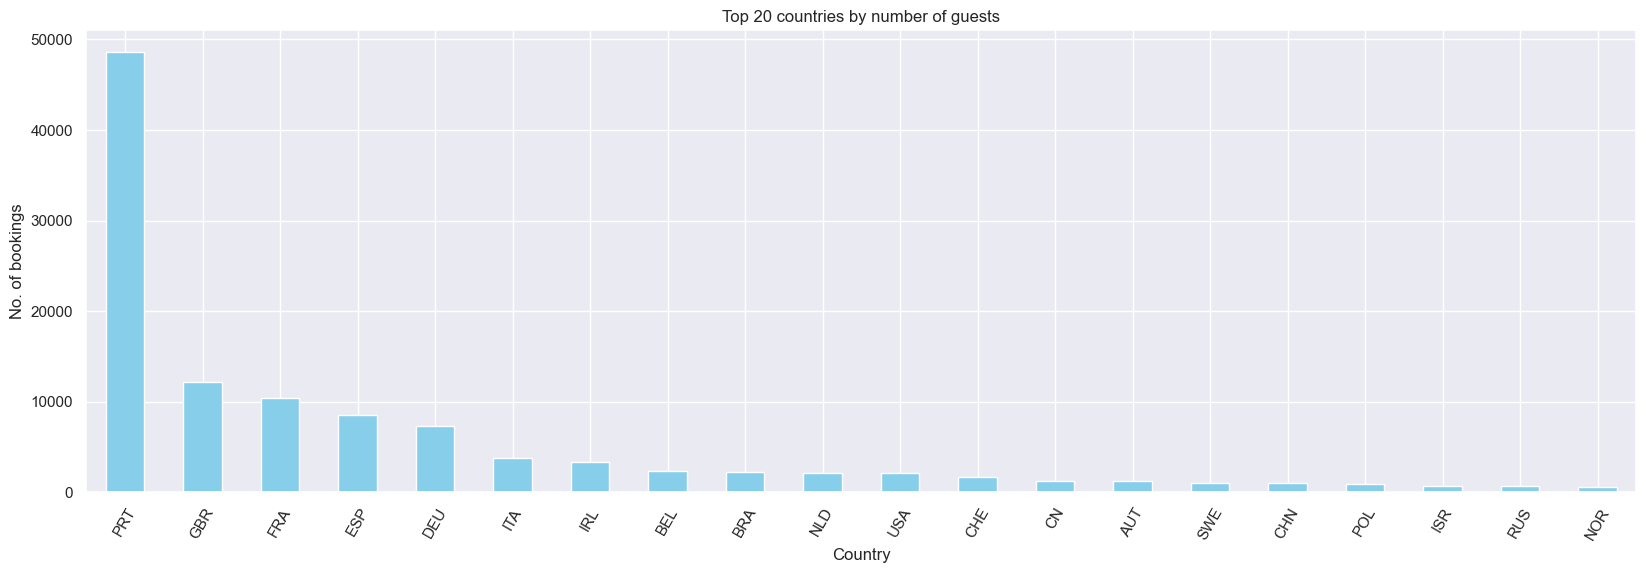

In [132]:
plt.figure(figsize=(20,6))
data_country.sort_values(ascending=False)[:20].plot(kind='bar',color='skyblue')
plt.xticks(rotation=60)
plt.xlabel("Country")
plt.ylabel("No. of bookings")
plt.title("Top 20 countries by number of guests")

In [ ]:
### BOOKING TYPE BY COUNTRY

Text(0.5, 1.0, 'Booked Hotel type by country')

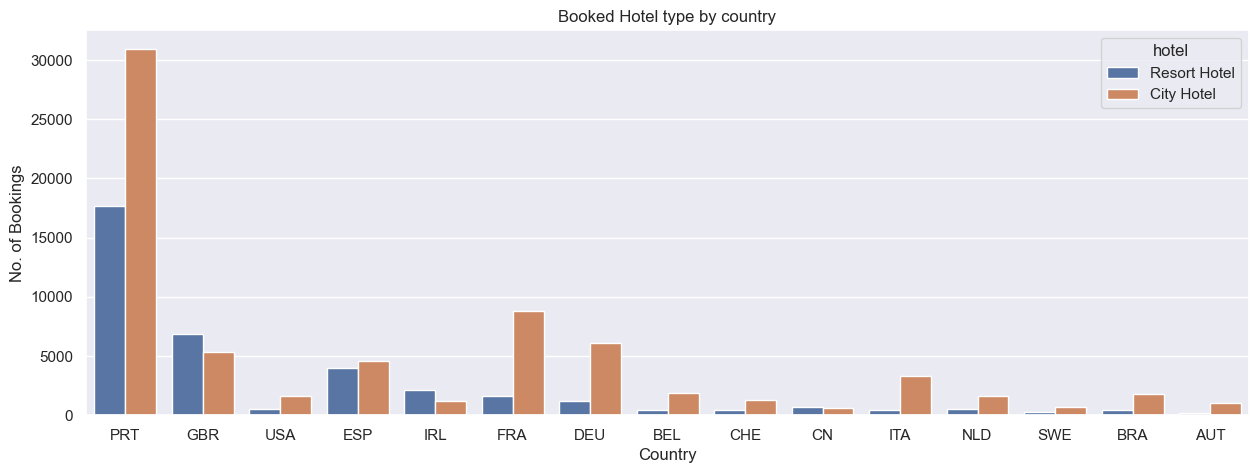

In [133]:
d = df['country'].value_counts().sort_values(ascending=False)[:15]
plt.figure(figsize=(15,5))
sns.countplot(x='country', hue='hotel', data=df[df['country'].isin(d.index)])
plt.xlabel("Country")
plt.ylabel("No. of Bookings")
plt.title("Booked Hotel type by country")

In [135]:
df['adr'].describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

Text(0.5, 1.0, 'Daily Rate by hotel type')

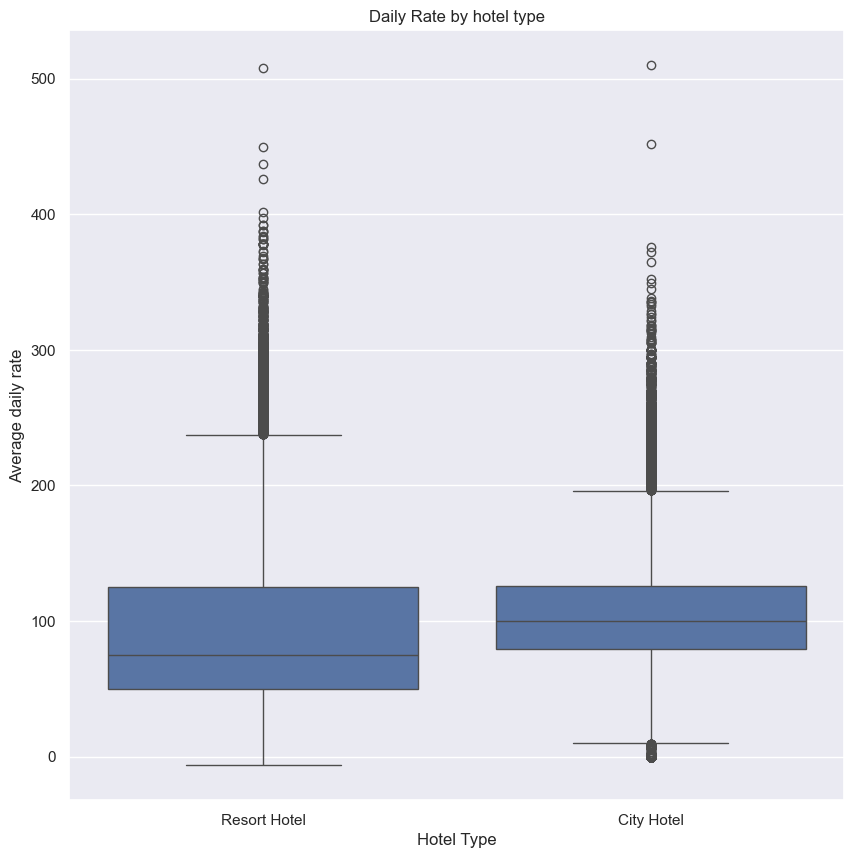

In [138]:
plt.figure(figsize=(10,10))
df2 = df.drop(df[df['adr']==5400].index, axis=0, inplace=False)  # Removed an extreme outlier (adr=5400) that made boxplot very squeezed to view
sns.boxplot(x='hotel', y='adr', data = df2)
plt.ylabel('Average daily rate')
plt.xlabel("Hotel Type")
plt.title("Daily Rate by hotel type")

Text(0.5, 1.0, 'Daily rate by hotel type')

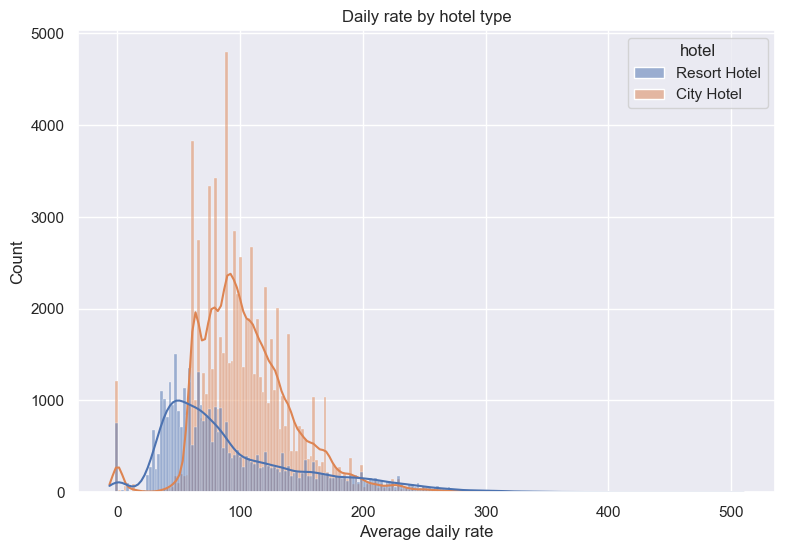

In [140]:
plt.figure(figsize=(9,6))
sns.histplot(x='adr', hue='hotel', data=df2, kde=True)
plt.xlabel("Average daily rate")
plt.title("Daily rate by hotel type")

In [ ]:
### PRICE VARIATIONS OVER THE YEAR 

In [143]:
d = df2.groupby(['hotel', 'arrival_date_month'])['adr'].mean().reset_index()
d['arrival_date_month'] = pd.Categorical(d['arrival_date_month'], categories=Months, ordered=True)
d.sort_values('arrival_date_month', inplace=True)

In [144]:
d

,hotel,arrival_date_month,adr
4,City Hotel,January,82.628986
16,Resort Hotel,January,49.461883
3,City Hotel,February,85.088278
15,Resort Hotel,February,55.171930
7,City Hotel,March,91.821162
19,Resort Hotel,March,57.520147
0,City Hotel,April,111.251838
12,Resort Hotel,April,77.849496
20,Resort Hotel,May,78.758134
8,City Hotel,May,121.638560


Text(0.5, 1.0, 'Average Daily rate by months')

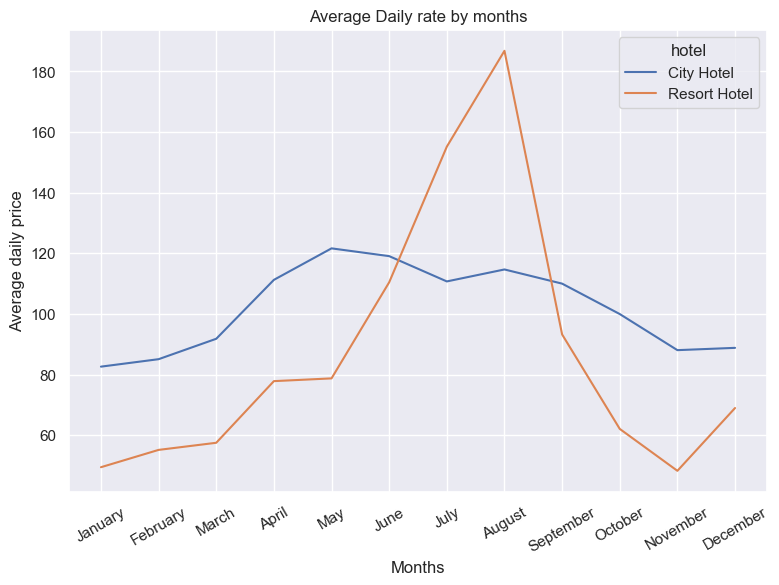

In [145]:
plt.figure(figsize=(9,6))
sns.lineplot(x='arrival_date_month', y='adr', hue='hotel', data=d)
plt.ylabel("Average daily price")
plt.xlabel("Months")
p = plt.xticks(rotation=30)
plt.title("Average Daily rate by months")

In [ ]:
###DAILY RATE BY CUSTOMER TYPES

Text(0.5, 1.0, 'Daily rate by customer type')

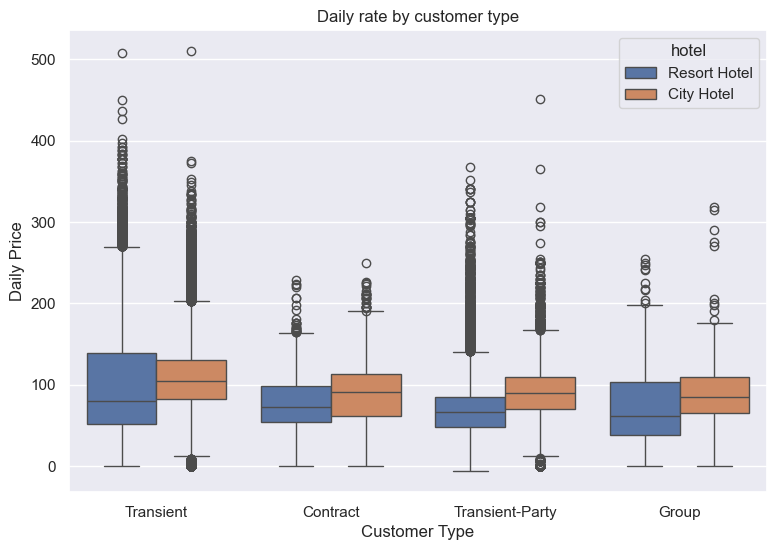

In [146]:
plt.figure(figsize=(9,6))
sns.boxplot(x='customer_type', y='adr', hue='hotel', data=df2)
plt.ylabel("Daily Price")
plt.xlabel("Customer Type")
plt.title("Daily rate by customer type")

In [ ]:
###BOOKING BY MARKET SEGMENTS

Text(0.5, 1.0, 'Bookings by market segment')

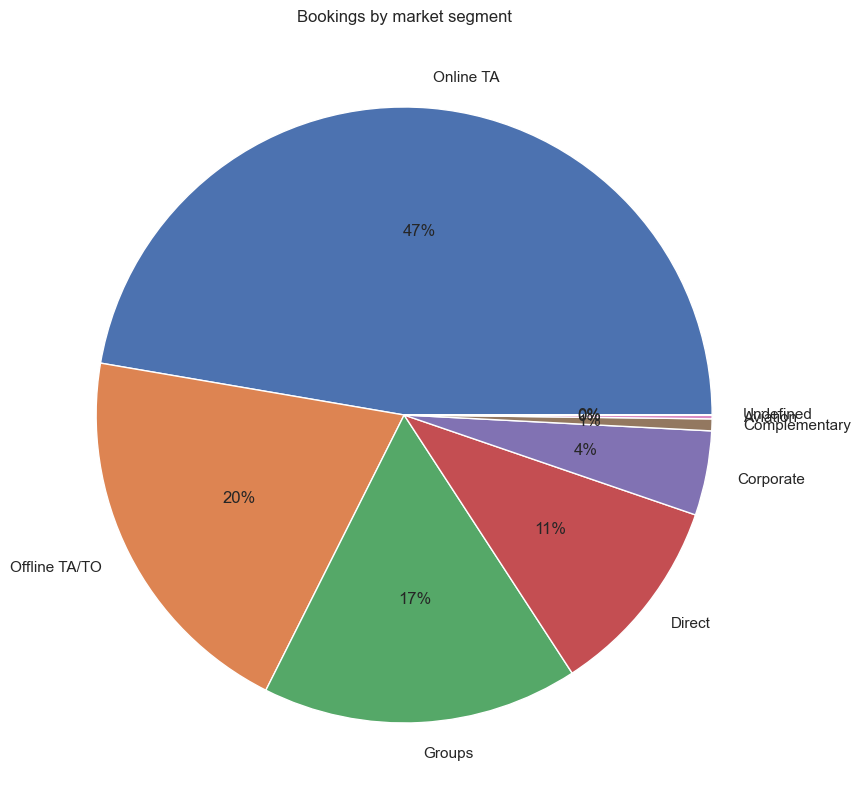

In [151]:
d = df['market_segment'].value_counts()
plt.figure(figsize=(10,10))
p = plt.pie(d, labels=d.index, autopct="%.0f%%")
plt.title("Bookings by market segment")

In [152]:
###BOOKING BY DISTRIBUTION CHANNEL

SyntaxError: invalid syntax (1229108749.py, line 1)

Text(0.5, 1.0, 'Bookings by distribution channel')

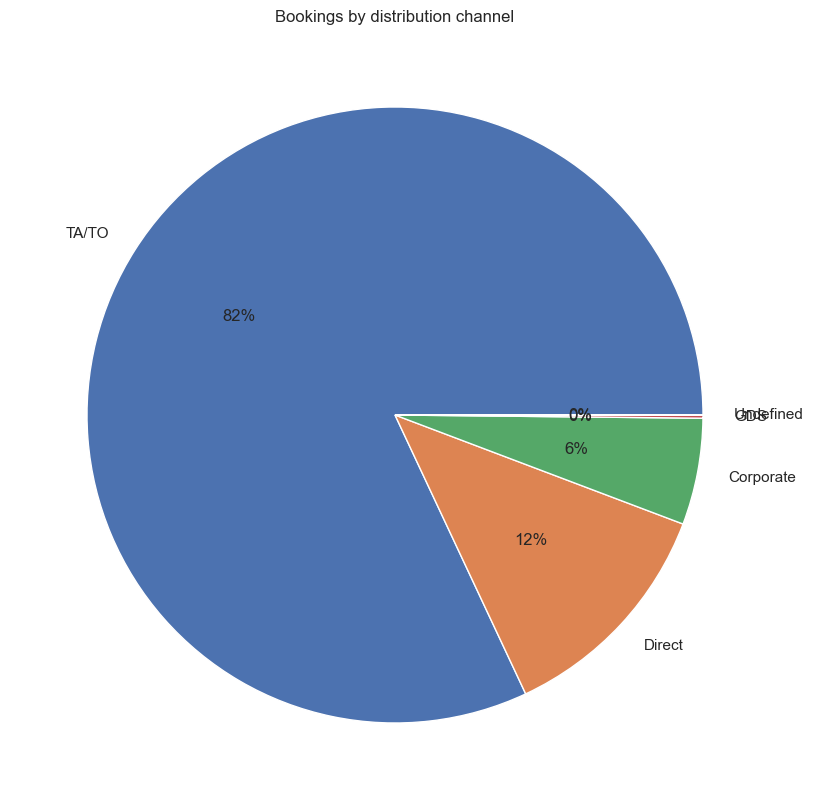

In [153]:
d = df['distribution_channel'].value_counts()
plt.figure(figsize=(10,10))
p = plt.pie(d, labels=d.index, autopct="%.0f%%")
plt.title("Bookings by distribution channel")

In [ ]:
###PERCENTAGE OF BOOKINGS WITH MEALS

Text(0.5, 1.0, 'Portion of bookings with meals and its type')

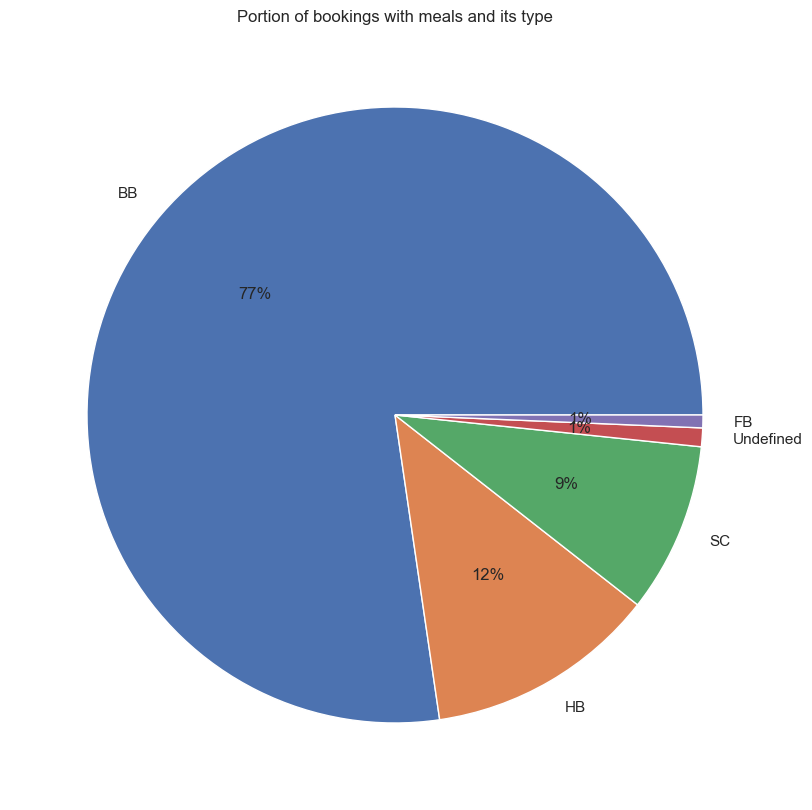

In [154]:
d = df['meal'].value_counts()
plt.figure(figsize=(10,10))
p = plt.pie(d, labels=d.index, autopct="%.0f%%")
plt.title("Portion of bookings with meals and its type")

In [ ]:
###NOM DAYS IN ADVANCED OF BOOKING HOTEL

Text(0.5, 1.0, 'Days in advanced of booking the hotel')

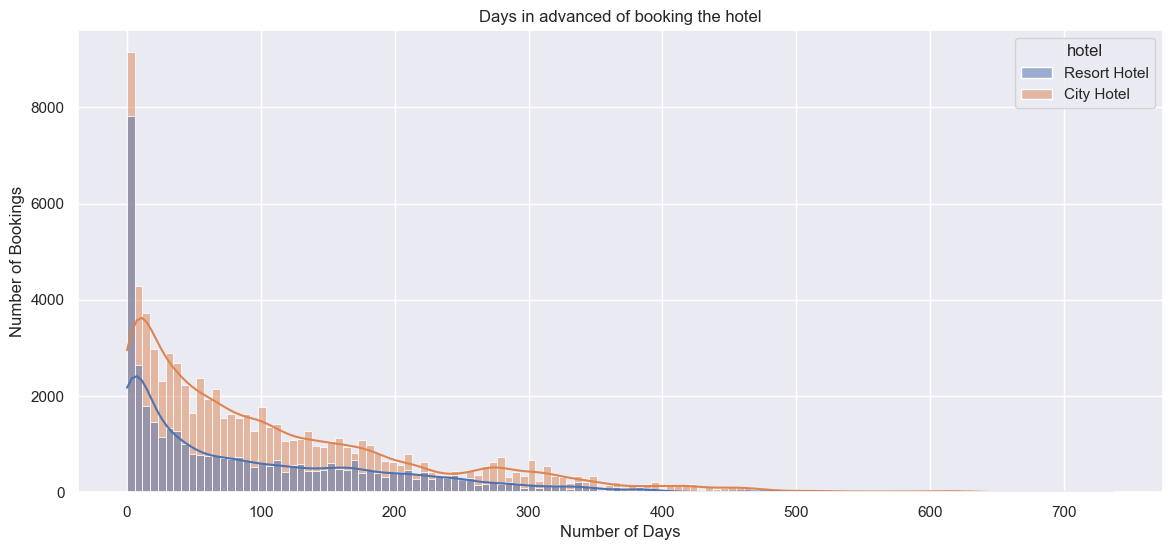

In [155]:
plt.figure(figsize=(14,6))
sns.histplot(x='lead_time', hue='hotel', data=df2, kde=True)
plt.xlabel("Number of Days")
plt.ylabel("Number of Bookings")
plt.title("Days in advanced of booking the hotel")

In [ ]:
###ADVANCE BOOKING VS DAILY RATE

In [156]:
d = df2.groupby(['hotel','lead_time']).agg({'adr': 'mean'}).rename(columns={'adr':'mean_adr'}).reset_index()

In [158]:
d.head(5)

,hotel,lead_time,mean_adr
0,City Hotel,0,94.884033
1,City Hotel,1,101.462665
2,City Hotel,2,105.799673
3,City Hotel,3,104.919491
4,City Hotel,4,102.936103


Text(0, 0.5, 'Daily Rate')

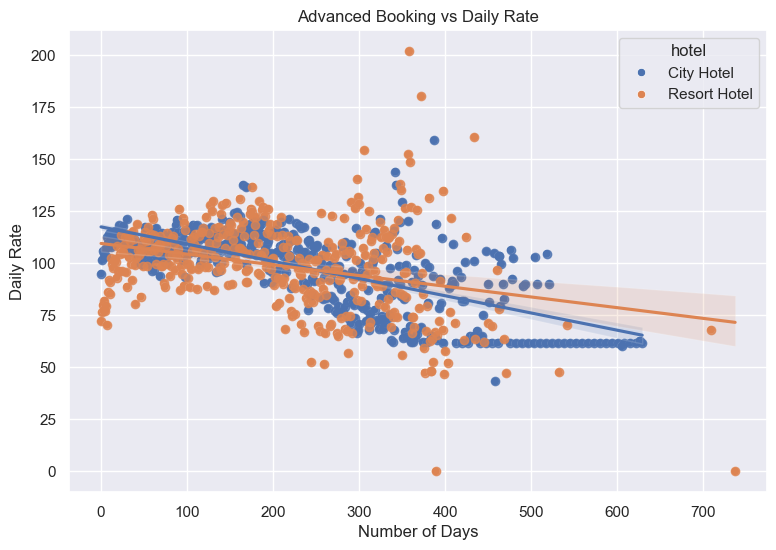

In [161]:
plt.figure(figsize=(9,6))
sns.scatterplot(x='lead_time', y='mean_adr', hue='hotel', data=d)
plt.title("Advanced Booking vs Daily Rate")
sns.regplot(x='lead_time', y='mean_adr', data=d[d['hotel']=='City Hotel'])
sns.regplot(x='lead_time', y='mean_adr', data=d[d['hotel']=='Resort Hotel'])
plt.xlabel("Number of Days")
plt.ylabel("Daily Rate")

In [ ]:
###SPECIAL REQUESTS

Text(0.5, 1.0, 'Top 50 countries by average number of special requests')

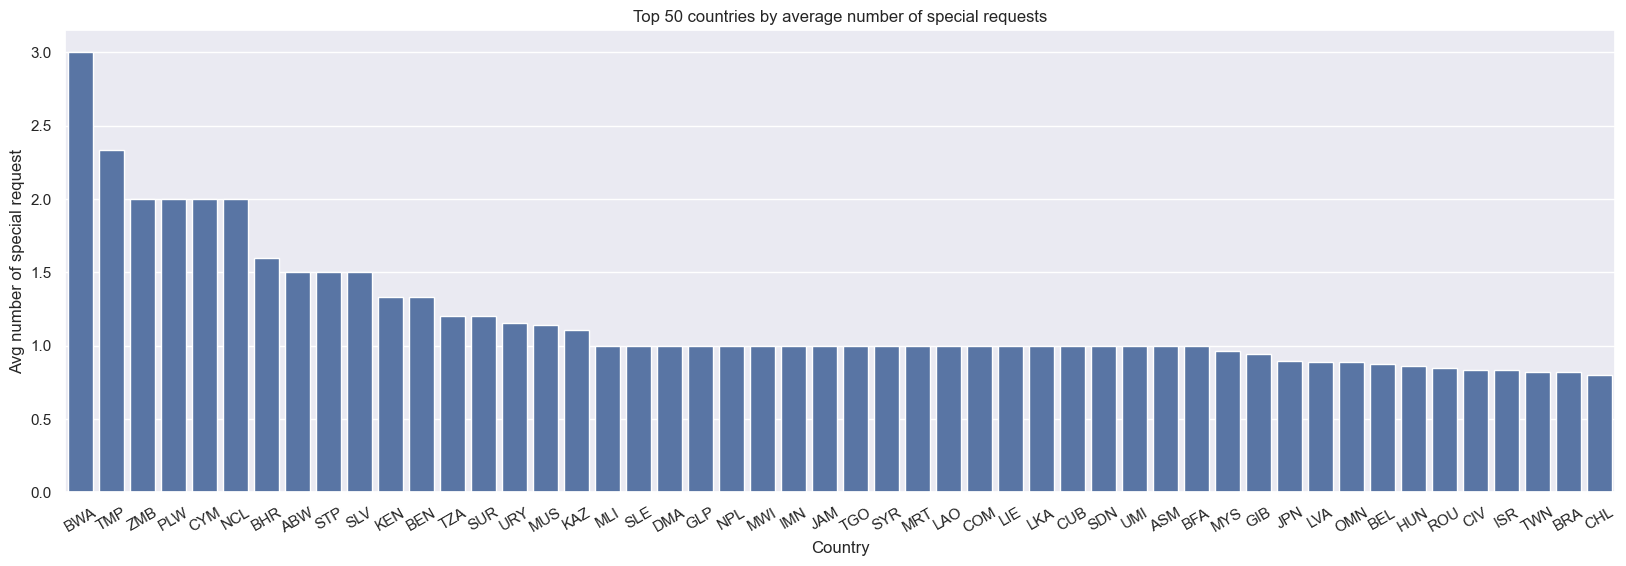

In [162]:
d = df.groupby("country")['total_of_special_requests'].mean().sort_values(ascending=False)[:50]
plt.figure(figsize=(20,6))
sns.barplot(x=d.index, y=d)
p = plt.xticks(rotation=30)
plt.xlabel("Country")
plt.ylabel("Avg number of special request")
plt.title("Top 50 countries by average number of special requests")

In [ ]:
###SPECIAL REQUESTS BY CUSTOMER TYPE

Text(0.5, 1.0, 'Average number of special requests by customer type')

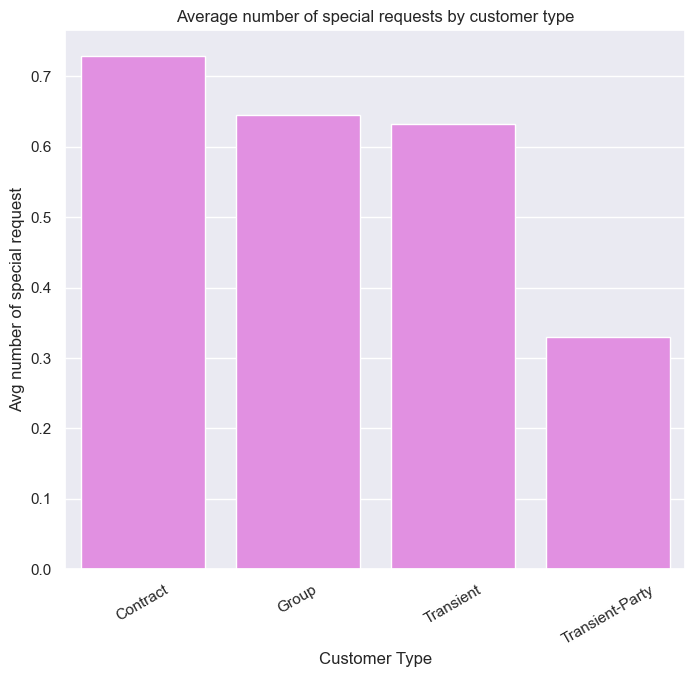

In [164]:
d = df.groupby("customer_type")['total_of_special_requests'].mean()
plt.figure(figsize=(8,7))
sns.barplot(x=d.index, y=d,color='violet')
p = plt.xticks(rotation=30)
plt.xlabel("Customer Type")
plt.ylabel("Avg number of special request")
plt.title("Average number of special requests by customer type")

In [165]:
df2.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

Text(0.5, 1.0, 'Avg Special Requests made pre guest across months in a year')

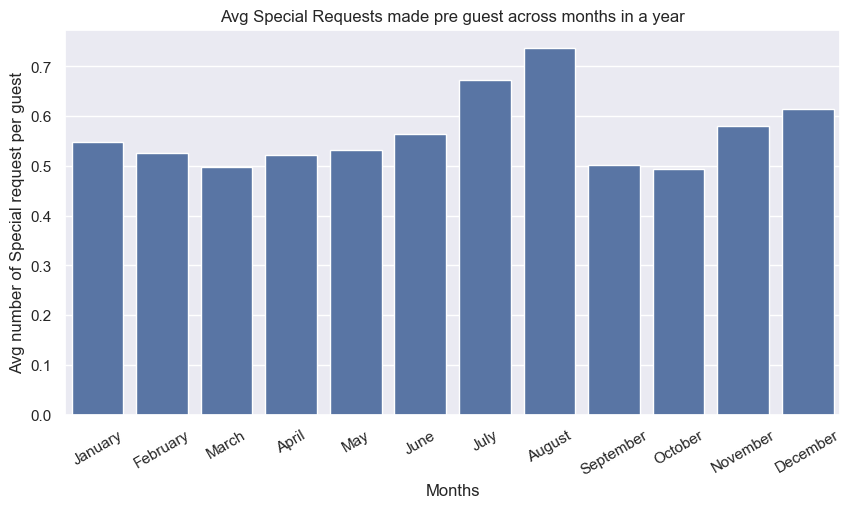

In [175]:
d = df.groupby('arrival_date_month')['total_of_special_requests'].mean()
plt.figure(figsize=(10,5))
sns.barplot(x=d.index, y=d, order=Months)
p = plt.xticks(rotation=30)
plt.xlabel("Months")
plt.ylabel("Avg number of Special request per guest")
plt.title("Avg Special Requests made pre guest across months in a year")

In [176]:
###HOTEL PREFERENCE BY CUSTOMER TYPE

SyntaxError: invalid syntax (743233264.py, line 1)

Text(0.5, 1.0, 'Hotel Preference by customer type')

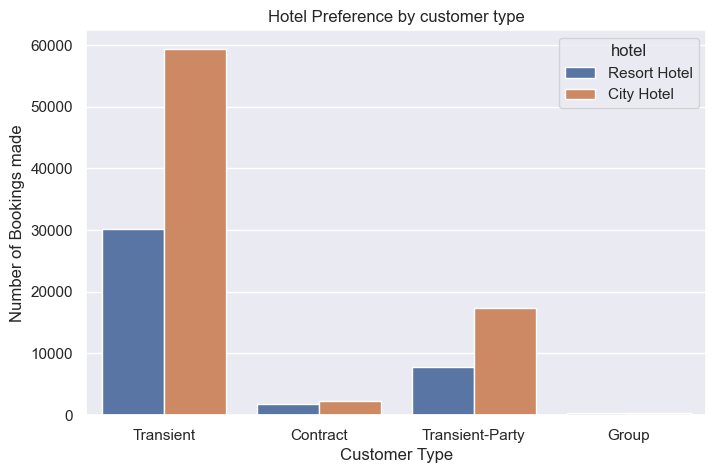

In [177]:
plt.figure(figsize=(8,5))
sns.countplot(x='customer_type', hue='hotel', data=df)
plt.xlabel("Customer Type")
plt.ylabel("Number of Bookings made")
plt.title("Hotel Preference by customer type")

In [ ]:
###NO OF  DAYS STAYED  BY DIFFENRT MARKET SEGEMENT

Text(0.5, 1.0, 'Week Days stayed by different market segment')

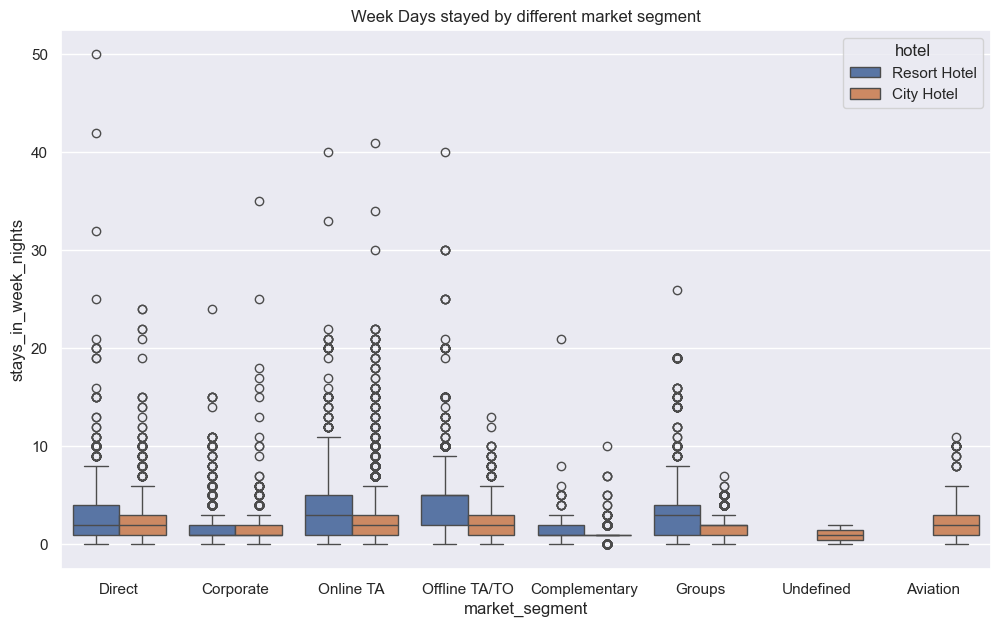

In [178]:
plt.figure(figsize = (12,7))
sns.boxplot(x = "market_segment", y = "stays_in_week_nights", hue = "hotel", data = df)
plt.title("Week Days stayed by different market segment")

In [ ]:
###CANCELLATIONS

In [180]:
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [181]:
d = df.groupby(['hotel','arrival_date_month']).agg({'is_canceled':'sum', 'meal':'count'}).reset_index().rename(columns={'is_canceled':'cancelled_bookings', 'meal':'total_bookings'})
d['cancellation_percentage'] = (d['cancelled_bookings']/d['total_bookings'])*100
d.head()

,hotel,arrival_date_month,cancelled_bookings,total_bookings,cancellation_percentage
0,City Hotel,April,3465,7480,46.323529
1,City Hotel,August,3602,8983,40.097963
2,City Hotel,December,1740,4132,42.110358
3,City Hotel,February,1901,4965,38.288016
4,City Hotel,January,1482,3736,39.668094


Text(0.5, 1.0, 'Cancellations per month')

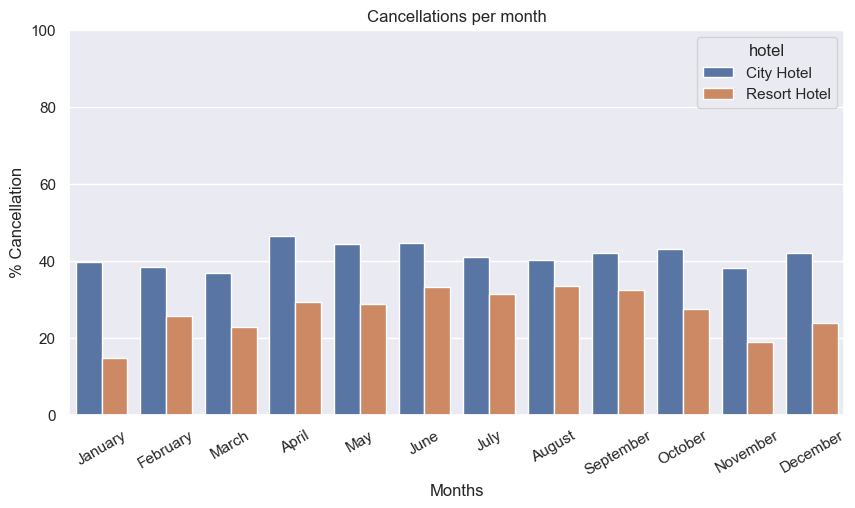

In [183]:
plt.figure(figsize=(10,5))
sns.barplot(x='arrival_date_month', y='cancellation_percentage', hue='hotel', data=d, order=Months)
plt.ylim((0,100))
plt.xticks(rotation=30)
plt.xlabel("Months")
plt.ylabel("% Cancellation")
plt.title("Cancellations per month")

In [ ]:
Effect of Lead time on Cancellations

In [184]:
d = df.groupby('lead_time').agg({'is_canceled':'sum', 'hotel':'count'}).reset_index().rename(columns={'is_canceled':'cancelled_bookings', 'hotel':'total_bookings'})
d['cancellation_percentage'] = (d['cancelled_bookings']/d['total_bookings'])*100
d.head()

,lead_time,cancelled_bookings,total_bookings,cancellation_percentage
0,0,430,6345,6.776990
1,1,321,3460,9.277457
2,2,213,2069,10.294828
3,3,182,1816,10.022026
4,4,176,1715,10.262391


Text(0.5, 1.0, 'Effect of Lead time on Cancellations')

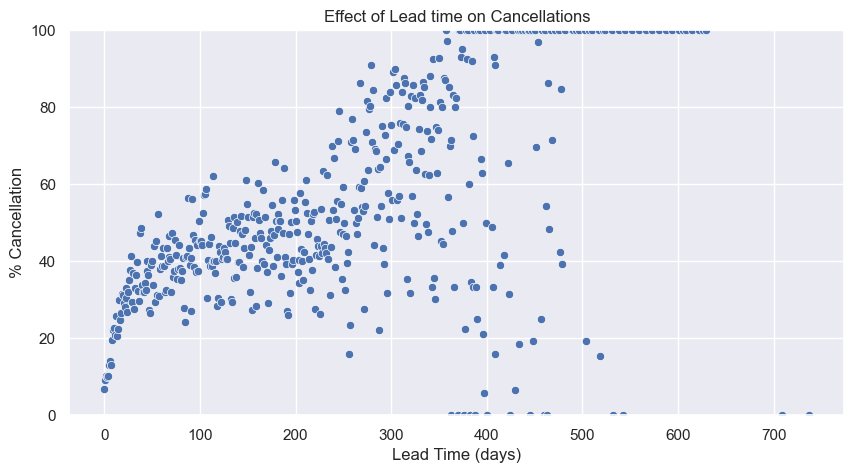

In [185]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='lead_time', y='cancellation_percentage', data=d)
plt.ylim((0,100))
plt.xlabel("Lead Time (days)")
plt.ylabel("% Cancellation")
plt.title("Effect of Lead time on Cancellations")

In [ ]:
### Cancellations by type of Guests (Repeated/NonRepeated)

Text(0.5, 1.0, 'Cancellations by repeated guests')

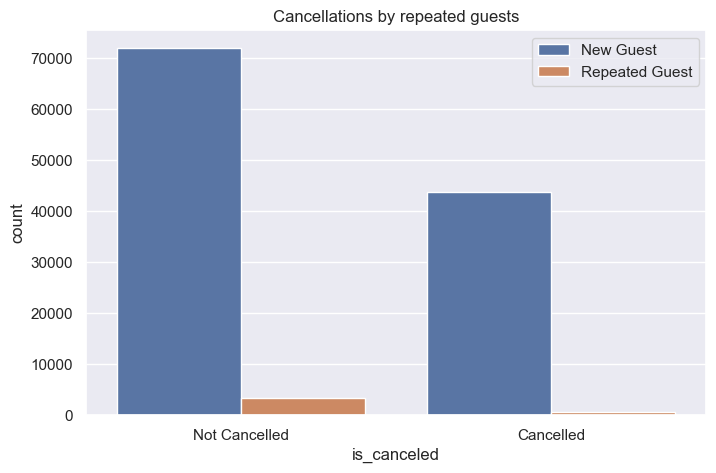

In [186]:
plt.figure(figsize=(8,5))
sns.countplot(x = "is_canceled", hue = 'is_repeated_guest', data = df)
plt.legend(['New Guest', 'Repeated Guest'])
plt.xticks(ticks=[0,1], labels=['Not Cancelled', 'Cancelled'])
plt.title("Cancellations by repeated guests")

Text(0.5, 1.0, 'Cancellation by Market Segments')

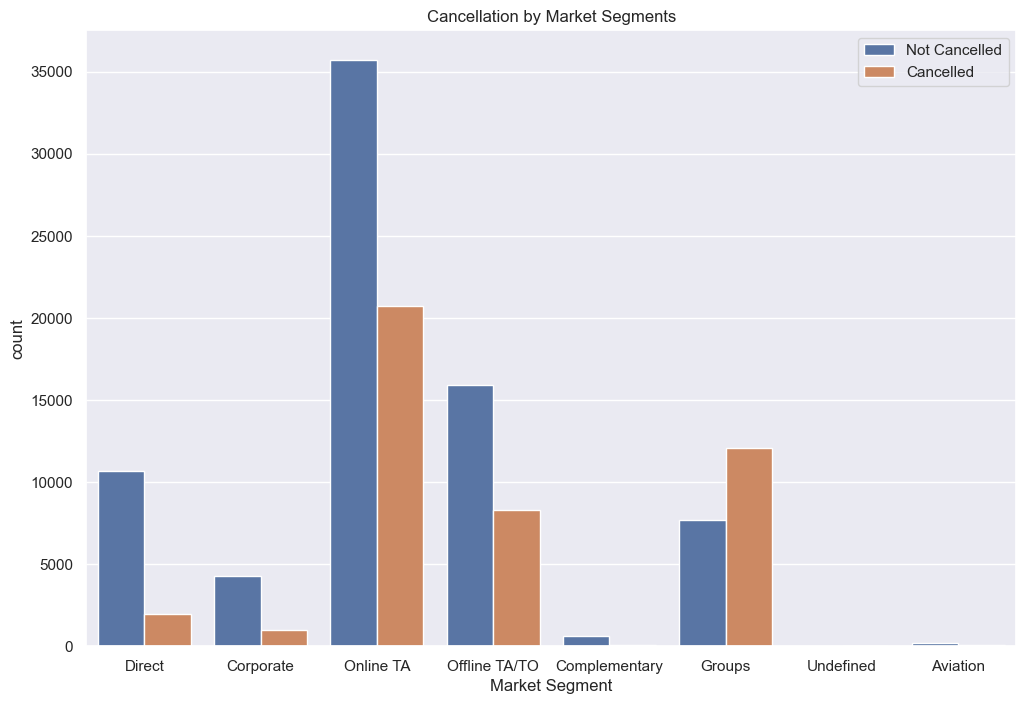

In [188]:
plt.figure(figsize = (12,8))
sns.countplot(x = "market_segment", hue = 'is_canceled', data = df)
plt.xlabel("Market Segment")
plt.legend(['Not Cancelled', 'Cancelled'])
plt.title("Cancellation by Market Segments")

In [ ]:
### CAR APRKING SPACE 

Text(0.5, 1.0, 'Car Parking Spaces Demand')

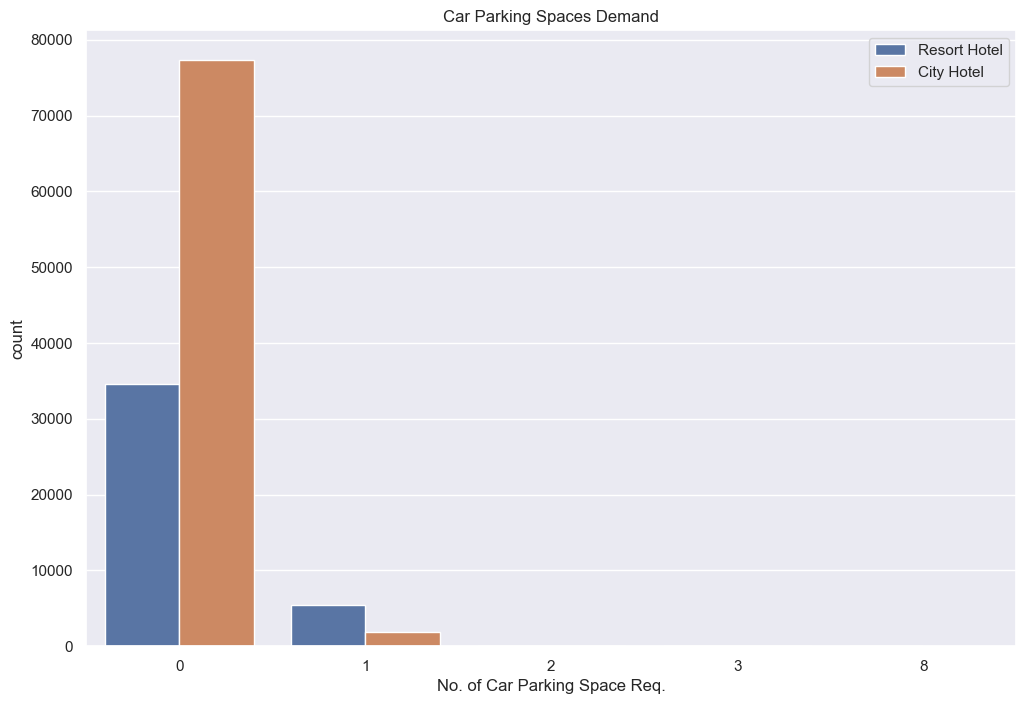

In [189]:
plt.figure(figsize = (12,8))
sns.countplot(x='required_car_parking_spaces', hue='hotel', data=df)
plt.xlabel("No. of Car Parking Space Req.")
plt.legend(loc=1)
plt.title("Car Parking Spaces Demand")

In [190]:
d = df.groupby('required_car_parking_spaces')['hotel'].count().reset_index().rename(columns={'hotel':'total_demand'})
d['demand_percentage'] = (d['total_demand']/sum(d['total_demand']))*100
d

,required_car_parking_spaces,total_demand,demand_percentage
0,0,111974,93.788424
1,1,7383,6.183935
2,2,28,0.023453
3,3,3,0.002513
4,8,2,0.001675


In [ ]:
### ROOM TYPE 

In [191]:
sorted(df['reserved_room_type'].unique())

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'L', 'P']

Text(0.5, 1.0, 'Types of Rooms reserved')

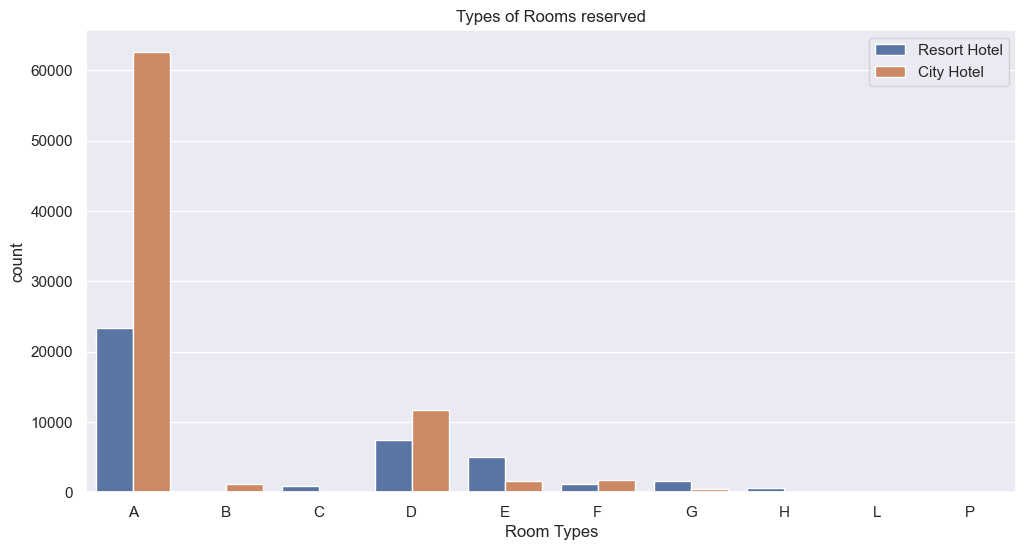

In [192]:
plt.figure(figsize = (12,6))
sns.countplot(x='reserved_room_type', hue='hotel', data=df, order=sorted(df['reserved_room_type'].unique()))
plt.xlabel("Room Types")
plt.legend(loc=1)
plt.title("Types of Rooms reserved")

Text(0.5, 1.0, 'Types of Rooms assigned')

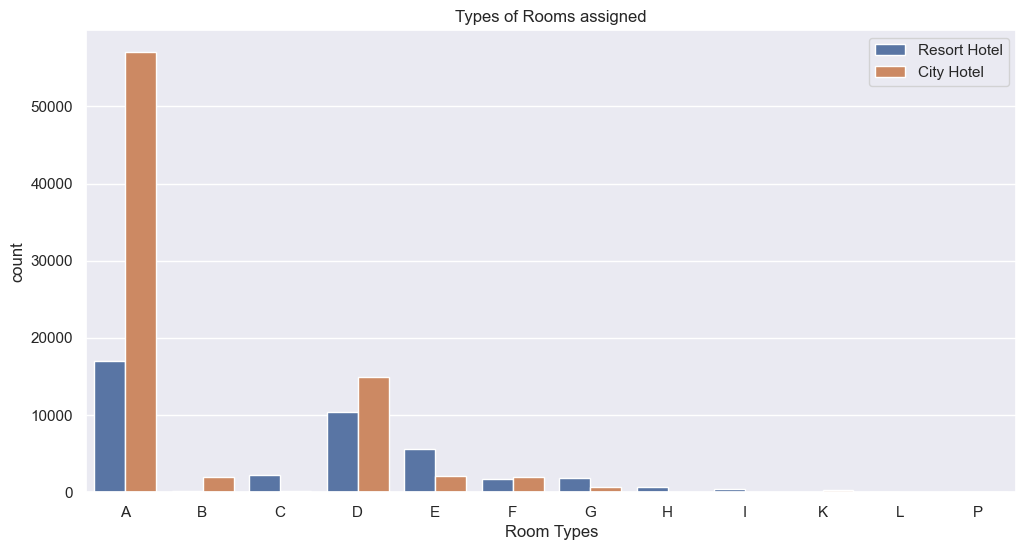

In [193]:
plt.figure(figsize = (12,6))
sns.countplot(x='assigned_room_type', hue='hotel', data=df, order=sorted(df['assigned_room_type'].unique()))
plt.xlabel("Room Types")
plt.legend(loc=1)
plt.title("Types of Rooms assigned")

In [ ]:
####. MOST DENIED ROOM TYPES

Text(0.5, 1.0, 'Most Denied Room Types')

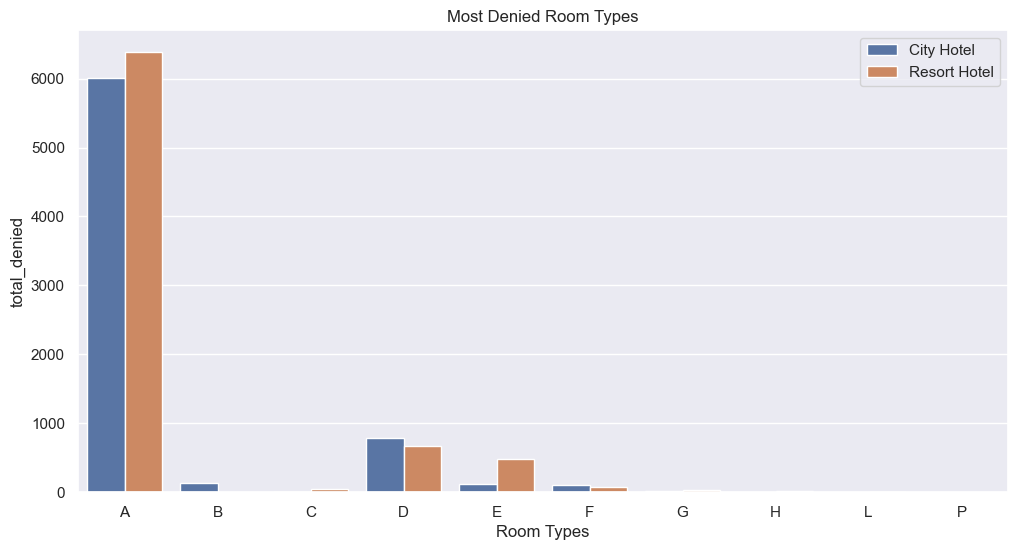

In [194]:
d = df.loc[df['reserved_room_type'] != df['assigned_room_type']].groupby(['reserved_room_type','hotel'])['meal'].count().reset_index().rename(columns={'meal':'total_denied'})

plt.figure(figsize = (12,6))
sns.barplot(x='reserved_room_type', y='total_denied', hue='hotel', data=d, order=sorted(df['reserved_room_type'].unique()))
plt.xlabel("Room Types")
plt.legend(loc=1)
plt.title("Most Denied Room Types")